In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 88s 1us/step


(50000, 32, 32, 3)

In [3]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [4]:
y_test = y_test.reshape(-1,)
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

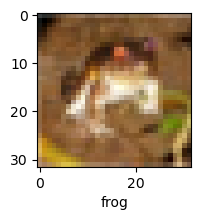

In [5]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])
plot_sample(X_train, y_train, 0)

Normalizing the training data

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Build simple artificial neural network for image classification

In [7]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='sigmoid')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

/Users/abhi/miniconda3/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3556 - loss: 1.8074
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4256 - loss: 1.6192
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4562 - loss: 1.5396
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4765 - loss: 1.4806
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4969 - loss: 1.4304


In [8]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.46      0.69      0.55      1000
           1       0.58      0.61      0.59      1000
           2       0.40      0.30      0.34      1000
           3       0.41      0.22      0.29      1000
           4       0.40      0.45      0.42      1000
           5       0.43      0.37      0.40      1000
           6       0.52      0.54      0.53      1000
           7       0.63      0.47      0.54      1000
           8       0.69      0.51      0.58      1000
           9       0.44      0.70      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



Now let us build a convolutional neural network to train our images

In [9]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/Users/abhi/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4779 - loss: 1.4541
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6217 - loss: 1.0795
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6719 - loss: 0.9420
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7055 - loss: 0.8496
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7295 - loss: 0.7773
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7475 - loss: 0.7198
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7676 - loss: 0.6695
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7863 - loss: 0.6134
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7987 - loss: 0.5733
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8151 - loss: 0.5284


In [11]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7037 - loss: 0.9290


[0.9289765357971191, 0.7037000060081482]

In [12]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[4.05009650e-03, 8.26880478e-06, 7.81908166e-03, 7.88224936e-01,
        5.24677045e-04, 1.96696863e-01, 2.54377676e-03, 3.44369000e-05,
        8.28470656e-05, 1.49309217e-05],
       [8.68856814e-03, 6.96898857e-03, 2.86325994e-05, 1.23365689e-05,
        3.62245737e-06, 3.60858579e-08, 6.64967015e-09, 7.22666194e-09,
        9.81220067e-01, 3.07768723e-03],
       [2.09604785e-01, 1.16881736e-01, 7.11055589e-04, 1.50634758e-02,
        1.41523755e-03, 3.02998989e-04, 9.37414807e-05, 3.11606214e-04,
        4.57474262e-01, 1.98141009e-01],
       [9.10532832e-01, 3.97588238e-02, 1.29516888e-02, 1.52971514e-03,
        1.00399600e-02, 2.56380208e-05, 6.03413326e-04, 8.90731735e-06,
        2.17279363e-02, 2.82105408e-03],
       [6.81034891e-08, 1.32011678e-06, 6.11611549e-03, 3.06863314e-03,
        9.50069547e-01, 1.47354949e-04, 4.05958183e-02, 6.31615819e-07,
        3.81306876e-07, 5.29680761e-08]], dtype=float32)

In [13]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [14]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

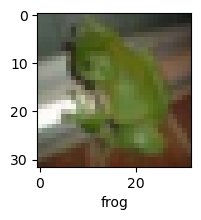

In [16]:
plot_sample(X_test, y_test,7)

In [17]:
classes[y_classes[7]]

'frog'